# Investigating parameters effects on Sensitivity of the OGGM Mass Balance and Runoff Models

In this notebook we will explore the sensitivity of OGGM's mass-balance and runoff models using SAFE. We will focus on the three parameters: melt factor, precipitation factor and temperature bias.

We will start by applying one-at-a-time sensitivity analysis to get a feel for how much each parameter affects the model and output. We will then consider the uncertainty of these sensitivities and work to quantify them.

## Sensitivity Analysis with the OGGM Mass Balance Model

We will apply sensitivity analysis in the following order to investigate our model behaviour:

1. **One-at-a-time**: We will apply one-at-a-time analysis , in which we change one parameter at a time and see how the mass balance changes in accordance. To show this, we will plot an interactive mass balance time series with toggles, where the parameter values can be changed within their default boundaries.
2. **Global sensitivity analysis**: Here we will use AAT sampling to randomly sample a combination of the 3 parameters and investigate the sensitivity in the following ways
    a. Qualitative - scatter plots
    b. Quantitative - RSA and bootstrapping

This will be applied first to the mass balance model in the OGGM, and then to the runoff model in the OGGM.

First we install the packages we require from both OGGM and SAFE.

In [7]:
import matplotlib.pyplot as plt
import os
import numpy as np
import scipy.stats as st
import pandas as pd

from oggm import cfg, workflow
from oggm.core import massbalance, flowline
from oggm import tasks
from oggm.core.massbalance import MultipleFlowlineMassBalance

# Install python package for interactive visualisation and import required functions:
%pip install -q ipywidgets
from ipywidgets import interact, fixed

# Install SAFE package and import required functions
%pip install SAFEpython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
import safepython.plot_functions as pf

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Now prepare to load the glacier directories from the OGGM.

In [18]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = "/mnt/c/Users/yg25019/Documents/sensitivity_output"
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2026-02-23 12:24:03: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-23 12:24:03: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-23 12:24:03: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-02-23 12:24:03: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-02-23 12:24:03: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-02-23 12:24:03: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [32]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-02-23 12:38:34: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-02-23 12:38:34: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


Creating the dataframe and adding the observed mass balance.

In [33]:
# Get the observed mass balance and set up dataframe
mbdf = gdir_hef.get_ref_mb_data().loc[1979:2019] # WGMS data for HEF
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[1979:2019]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

# Step 1 - The OGGM Runner, to produce runoff simulations

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

This runner will produce a timeseries for the runoff.

The method will use run_with_hydro to create the hydrological data required to calculate the runoff in the OGGM.

In [34]:
# Hydrological model workflow steps before running with hydro
cfg.PARAMS['evolution_model'] = 'FluxBased'
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['error_when_glacier_reaches_boundaries'] = False

The below method calculates the output metrics we will be using to understand the output of our hydrological simulations and our runoff timeseries. We currently do not have any observed data and so we are unsure of the values to expect, but we can still look into the mean and standard deviation, and use these in our sensitivity analysis.

Using the mean and standard deviation can give us a good picture of the data we have generated.

In [35]:
def hydro_output_metric_calculator(runoff):
    '''
    Calculates the output metrics for runoff, the mean and the standard deviation. 

    This is currently only used for calculting the mean and standard deviation of the runoff
    but can be added to in the future.

    Parameters:
    ------------

    runoff: np.array
        The runoff time series generated from the oggm_sim method, when the output is the runoff time series.

    Return:
    ------------

    YY: np.array
        An array containing the values of:
            - The annual runoff mean.
            - The annual runoff standard deviation.
    '''
    YY = np.nan * np.ones((len(runoff), 2))

    for i, x in enumerate(runoff):
        YY[i,0] = np.mean(x)
        YY[i,1] = np.std(x)

    return YY

In [40]:
def runoff_execution(fun_test, X, gdir,
                        years, init_model_yr, ys, min_ys,
                        ref_area_yr, spinup_period,
                        csv_filepath, run_task, mb_model_method):

    all_experiments = []

    # Shared parameters (same for all experiments)
    common = dict(
        years=years,
        init_model_yr=init_model_yr,
        ys=ys,
        min_ys=min_ys,
        ref_area_yr=ref_area_yr,
        spinup_period=spinup_period,
        csv_filepath=csv_filepath,
        run_task=run_task,
        mb_model_method=mb_model_method,
    )

    # One experiment per sample
    for i, sample_row in enumerate(X):
        kw = dict(common)
        kw.update(
            mb_params=sample_row,
            row_index=i,
            settings_filesuffix=f"_exp{i}"   # <-- IMPORTANT
        )
        all_experiments.append((gdir, kw))
    
    old_continue_one_error = cfg.PARAMS["continue_on_error"]
    cfg.PARAMS["continue_on_error"] = True
    # Run all experiments in parallel
    out_list = workflow.execute_entity_task(fun_test, all_experiments)

    cfg.PARAMS["continue_on_error"] = old_continue_one_error
    return hydro_output_metric_calculator(out_list)

In [ ]:
# import os
# from oggm import workflow, utils

# def runoff_execution(fun_test, X, gdir,
#                      years, init_model_yr, ys, min_ys,
#                      ref_area_yr, spinup_period,
#                      csv_filepath, run_task, mb_model_method):

#     all_experiments = []

#     # Shared parameters
#     common = dict(
#         years=years,
#         init_model_yr=init_model_yr,
#         ys=ys,
#         min_ys=min_ys,
#         ref_area_yr=ref_area_yr,
#         spinup_period=spinup_period,
#         csv_filepath=csv_filepath,
#         run_task=run_task,
#         mb_model_method=mb_model_method,
#     )

#     # Put all experiment gdirs under a tidy subfolder
#     exp_root = os.path.join(gdir.base_dir, "experiments")
#     os.makedirs(exp_root, exist_ok=True)

#     for i, sample_row in enumerate(X):
#         # A unique base_dir for this experiment
#         exp_base = os.path.join(exp_root, f"exp_{i}")
#         os.makedirs(exp_base, exist_ok=True)

#         # --- IMPORTANT ---
#         # Use the OGGM utility to copy/clone the glacier directory to a new base
#         # Different OGGM versions return either a single gdir or a list; handle both.
#         exp_gdir = utils.copy_to_basedir(gdir, base_dir=exp_base, setup='run')
#         # If the utility returns a list, take the first element
#         if isinstance(exp_gdir, (list, tuple)):
#             exp_gdir = exp_gdir[0]

#         kw = dict(common)
#         kw.update(
#             mb_params=sample_row,
#             row_index=i,
#             settings_filesuffix=f"_exp{i}",
#         )

#         all_experiments.append((exp_gdir, kw))

#     print("Launching runoff experiments in parallel...\n")
#     out_list = workflow.execute_entity_task(fun_test, all_experiments)

#     return hydro_output_metric_calculator(out_list)

# Calling this from the version in the OGGM - trying it to check that it works

In [36]:
cfg.PARAMS['use_multiprocessing'] = True  # To speed up sensitivity analysis runs
cfg.PARAMS['mp_processes'] = os.cpu_count()  # Use all available cores

In [48]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

# gdir_hef.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this? 
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 1.0, -3]) # Minimum values for each parameter
x_max = np.array([7.0, 5.0, 3]) # Maximum values for each parameter
# The default ranges error with the dynamic spinup, we need to reduce these ranges - ideally to something closer to the Hinteresfirner glacier to be able to complete a dynamic spinup
# Some of these output values are 0 for runoff, 
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 1000 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

YY = runoff_execution(fun_test = flowline.run_with_runoff, 
                 X = X, #All samples
                 gdir = gdir_hef, # Hinteresfirner Glacier directory
                 years =range(1979, 2019), # years
                 init_model_yr = 1901, # Simulation start year - needs to be early enough to allow for spinup before the period we are interested in
                 ys =1901, # Was 1979
                 min_ys = 1901, # Was 1979
                 ref_area_yr = 2004, # Reference area year - needs to be a year for which we have observed area data for the glacier, so we can use this to constrain the modelled glacier area during the spinup period
                 spinup_period = 21, # Spinup period in years (we are cutting this off, once the glacier has reached an equilibrium state, but this can be changed to a different period if desired)
                 csv_filepath = 'runoff_output.csv',
                 run_task = tasks.run_from_climate_data,
                 mb_model_method = MultipleFlowlineMassBalance) # 50s, how to verify if we are running in parallel or not? Message is currently wrong??, it says I am iterating over 50 glaciers rather than 50 samples.

2026-02-23 12:43:01: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2026-02-23 12:43:01: oggm.workflow: Execute entity tasks [run_with_runoff] on 1000 glaciers


2026-02-23 12:43:02: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-23 12:43:02: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-23 12:43:02: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-23 12:43:02: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-23 12:43:02: oggm.core.flowline: You are attempting to run_with_clim

In [49]:
X

array([[ 4.47976826,  4.6077099 ,  0.23991164],
       [ 4.58565177,  3.38832891,  2.4199645 ],
       [ 4.63186645,  3.71101519,  2.92776591],
       ...,
       [ 3.70201307,  2.69407732,  1.98470323],
       [ 3.03996366,  3.52964438,  2.09108897],
       [ 6.5315077 ,  2.00742686, -0.81980255]])

In [50]:
# Testing outputs match input index
# These seem to match what is present in the input and outputs
YY
# X[1]

array([[65.41586863,  7.49182061],
       [22.67331522,  2.38705013],
       [19.38972049,  1.66189659],
       ...,
       [22.92437859,  2.27828596],
       [34.18551638,  3.03935643],
       [23.79901901,  5.09715661]])

## Parameter Space Study

The OGGM uses extremely large default parameter ranges, that for specific glaciers are completely unrealistic. Here we perform some studies on the parameter space to understand which ranges are feasible, if there are any trends we can take into account for our data and if we can optimise our sampling approach. The outline of the methodology is as follows:
1. Sampling the parameter space uniformly with large ranges and an initial, qualitative investigation if any patterns emerge.
2. Comparison with the observed data we have avaliable: area and mass balance, we can investigate the combinations of parameters that cause a large deivation from the observed values.
    a. Here we can start with an AAT investigation, as our inputs are not independent.
3. From this initial study, it may become apparent that our ranges can be reduced. If this is obvious, we can reduce the ranges and resample with the updated parameter ranges.
4. Running the simulations again, we can now investigate the sampling strategy and distributions. From here some more complex techniques can be investigated and we can compare which behaves the best.

## Experiment #1: A uniform sampling of the OGGM's default sample space.

We start off simply with the OGGM's default sample space, which has large ranges for the melt_f, prcp_fac and temp_bias. We have used a uniform distribution to sample these in a LHS technique using AAT.

Firstly, lets plot the mass balance alongside the observed mass balance value to understand how much our outputs are currently varying from the parameters we are sampling and if there is a large difference between our simulated and observed values.

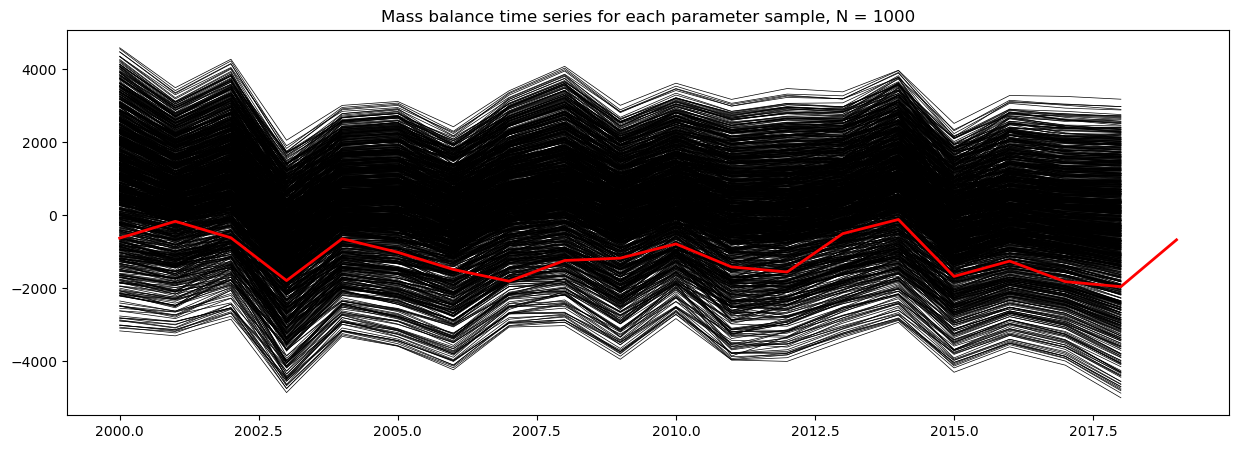

In [51]:
# compile csvs to plot timeseries and plot to view the mass balance time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
plt.figure(figsize=(15,5))

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    plt.plot(df['years'], df['mass_balance'], label='sim', color='k', linewidth=0.5)
    plt.title('Mass balance time series for each parameter sample, N = %d' % N)

plt.plot(range(2000,2020), mbdf['in_situ_mb'].loc[2000:2019], label='obs', color='r', linewidth=2)

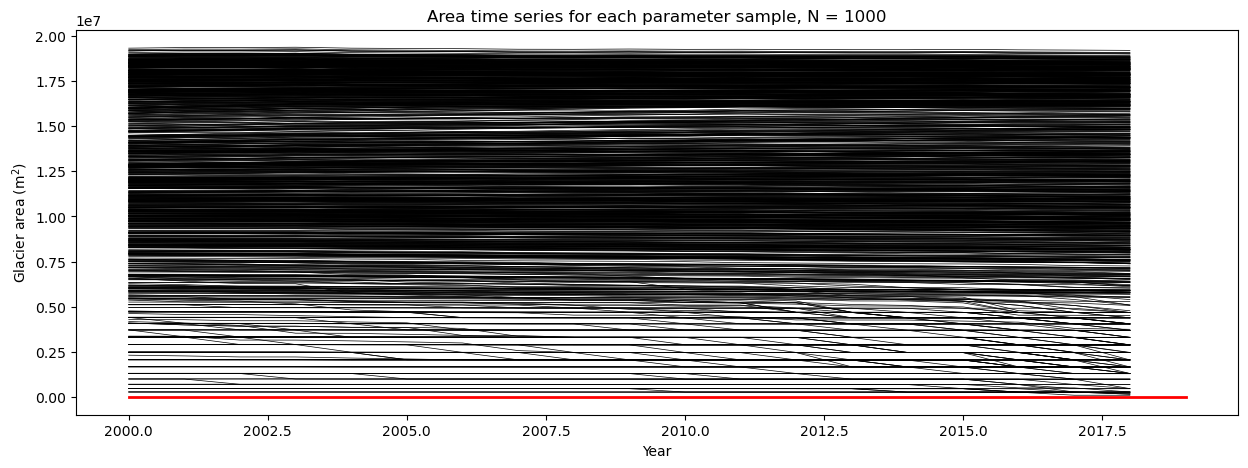

In [52]:
# compile csvs to plot timeseries and plot to view the mass balance time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
plt.figure(figsize=(15,5))

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    plt.plot(df['years'], df['area'], label='sim', color='k', linewidth=0.5)
    plt.title('Area time series for each parameter sample, N = %d' % N)

plt.ylabel('Glacier area (m$^2$)')
plt.xlabel('Year')
plt.plot(range(2000,2020), mbdf['AREA'].loc[2000:2019], label='obs', color='r', linewidth=2)

Text(0.5, 0, 'Year')

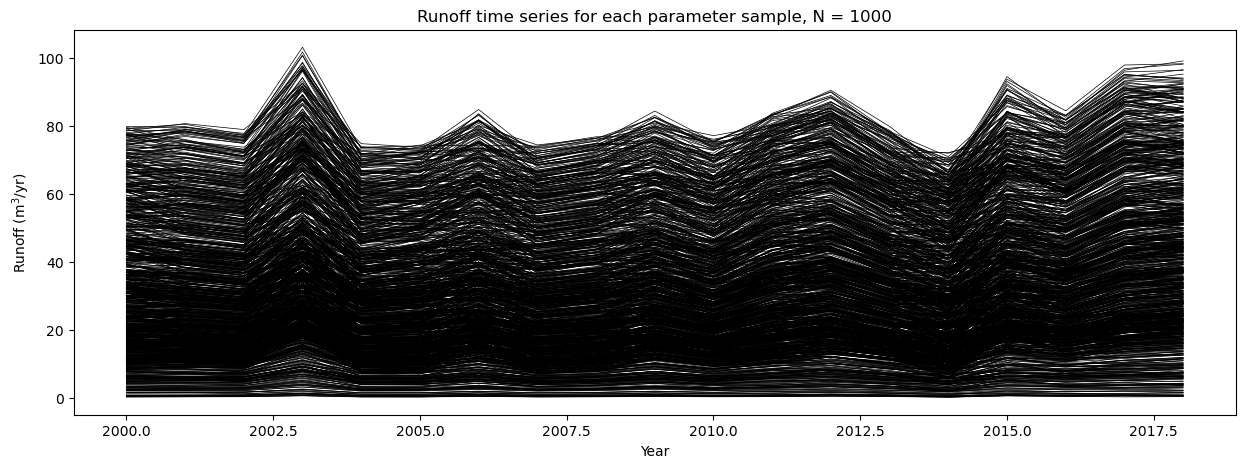

In [53]:
# compile csvs to plot timeseries and plot to view the runoff time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
plt.figure(figsize=(15,5))

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    plt.plot(df['years'], df['runoff'], label='sim', color='k', linewidth=0.5)
    plt.title('Runoff time series for each parameter sample, N = %d' % N)

plt.ylabel('Runoff (m$^3$/yr)')
plt.xlabel('Year')

Now, lets plot our two output metrics together the mean and standard deviation of the runoff.

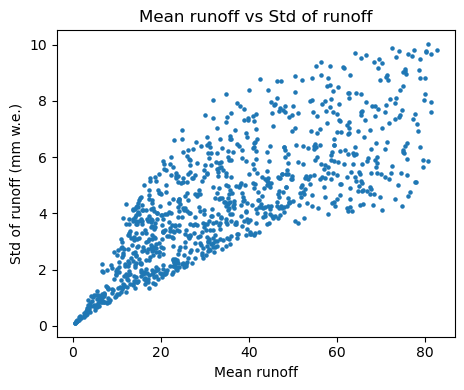

In [54]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),

plt.tight_layout()
plt.show()

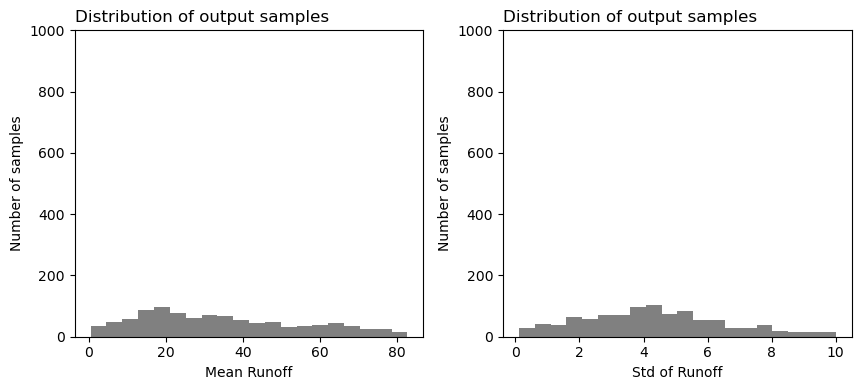

In [55]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,0], bins=20, color='grey');
plt.ylim((0,N)), plt.ylabel('Number of samples'), plt.xlabel(Y_lab_runoff_dist[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,1], bins=20, color='grey');
plt.ylim((0,N)), plt.ylabel('Number of samples'), plt.xlabel(Y_lab_runoff_dist[1])

plt.tight_layout()

## Investigation to reduce range

Now let's investigate which of these simulations are over +/- 30% away from the observed annual mass balance and area values.

In [ ]:
# # Now let's investigate which of these simulations are over +/- 30% away from the observed annual mass balance and area values.
# # plt.figure(figsize=(15,5))
# count = 0
# for i in range(N):
#     df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
#     if df['mass_balance'].mean() < 0.7 * mbdf['in_situ_mb'].mean() or df['mass_balance'].mean() > 1.3 * mbdf['in_situ_mb'].mean():
#         print(f"Sample {i} has mass balance outside 30% range of observed values")
#         count += 1
#     if df['area'].mean() < 0.7 * mbdf['AREA'].mean() or df['area'].mean() > 1.3 * mbdf['AREA'].mean():
#         print(f"Sample {i} has area outside 30% range of observed values")
#         # plt.plot(df['years'], df['area'], label='sim', color='r', linewidth=0.5)
# print(count)


Sample 0 has mass balance outside 30% range of observed values
Sample 0 has area outside 30% range of observed values
Sample 1 has mass balance outside 30% range of observed values
Sample 1 has area outside 30% range of observed values
Sample 2 has mass balance outside 30% range of observed values
Sample 2 has area outside 30% range of observed values
Sample 3 has mass balance outside 30% range of observed values
Sample 3 has area outside 30% range of observed values
Sample 4 has mass balance outside 30% range of observed values
Sample 4 has area outside 30% range of observed values
Sample 5 has mass balance outside 30% range of observed values
Sample 5 has area outside 30% range of observed values
Sample 6 has mass balance outside 30% range of observed values
Sample 6 has area outside 30% range of observed values
Sample 7 has mass balance outside 30% range of observed values
Sample 7 has area outside 30% range of observed values
Sample 8 has mass balance outside 30% range of observed 

In [ ]:
# import numpy as np
# import pandas as pd
# from pathlib import Path

# mb_obs = mbdf['in_situ_mb']  # observed mass balance series for comparison

# # --- USER SETTINGS ---
# rmse_max = 0.6     # m w.e. a^-1 threshold for "in-bounds"
# bias_max = 0.3     # optional, used in 'is_ok' if desired
# rel_cum_max = 0.3  # optional, used in 'is_ok' if desired

# # mb_obs must be a pandas Series indexed by int years
# # Example: mb_obs = mbdf_annual['ANNUAL_BALANCE']  (ensure it's aligned to int years)
# if not isinstance(mb_obs, pd.Series):
#     raise TypeError("mb_obs must be a pandas Series indexed by integer years")

# # Ensure observed index is integer years
# try:
#     mb_obs.index = mb_obs.index.astype(int)
# except Exception:
#     # If mb_obs.index are datetimes, convert to years
#     mb_obs.index = pd.to_datetime(mb_obs.index).year.astype(int)

# def compute_mb_metrics(mb_mod: pd.Series, mb_obs: pd.Series):
#     """Return RMSE, bias, and relative cumulative error between modelled and observed MB."""
#     # Align to common years
#     common_years = mb_mod.index.intersection(mb_obs.index)
#     if len(common_years) == 0:
#         return np.inf, np.inf, np.inf, common_years

#     m = mb_mod.loc[common_years]
#     o = mb_obs.loc[common_years]

#     diff = (m - o).values
#     rmse = np.sqrt(np.nanmean(diff**2))
#     bias = np.nanmean(diff)
#     rel_cum_err = np.abs(m.sum() - o.sum()) / (np.abs(o.sum()) + 1e-12)

#     return rmse, bias, rel_cum_err, common_years

# # Storage
# results = []
# series_store = []  # keep aligned series for plotting

# work_dir = Path(cfg.PATHS['working_dir'])

# for i in range(N):
#     csv_path = work_dir / f"{i}_runoff_output.csv"
#     if not csv_path.exists():
#         print(f"[warn] Missing file: {csv_path}")
#         continue

#     df = pd.read_csv(csv_path)

#     # Convert years to int index and build modelled MB series
#     years = pd.to_numeric(df['years'], errors='coerce').astype('Int64').astype(int)
#     mb_mod = pd.Series(df['mass_balance'].values, index=years)

#     # Compute metrics
#     rmse, bias, rel_cum_err, years_common = compute_mb_metrics(mb_mod, mb_obs)

#     # Classify (you can include bias/rel_cum_err if you want a compound rule)
#     is_ok = (rmse <= 600)  # simple rule; extend with bias/rel_cum if desired

#     # Store for later plotting: keep aligned modelled MB over common years
#     aligned_mod = mb_mod.loc[years_common]
#     aligned_obs = mb_obs.loc[years_common]
#     series_store.append({
#         'i': i,
#         'years': years_common.values,
#         'mb_mod': aligned_mod.values,
#         'mb_obs': aligned_obs.values,
#         'is_ok': is_ok,
#         'rmse': rmse,
#         'bias': bias,
#         'rel_cum_err': rel_cum_err
#     })

#     results.append((i, rmse, bias, rel_cum_err, is_ok))

# # Collect into DataFrame for quick inspection/sorting
# res_df = pd.DataFrame(results, columns=['sim', 'rmse', 'bias', 'rel_cum_err', 'is_ok']).sort_values('rmse')
# print(res_df.head())
# print(f"{res_df['is_ok'].sum()} of {len(res_df)} simulations are within RMSE ≤ {rmse_max}")

   sim          rmse          bias  rel_cum_err  is_ok
0    0   1922.085603  -1875.770686     1.636723  False
4    4   4514.355818   4478.307200     3.907593  False
3    3   6559.718727   6517.885787     5.687248  False
1    1   8588.828446  -8519.069466     7.433402  False
2    2  28895.088489 -28850.441821    25.173749  False
0 of 5 simulations are within RMSE ≤ 0.6


Let's investigate the RMSD as a means to investigate the overall fit of our simulations to the observed data. From this analysis, we can derive a set of parameters that are within a specific tolerance to attempt to tune our parameter ranges a bit more closely.

<Figure size 1500x500 with 0 Axes>

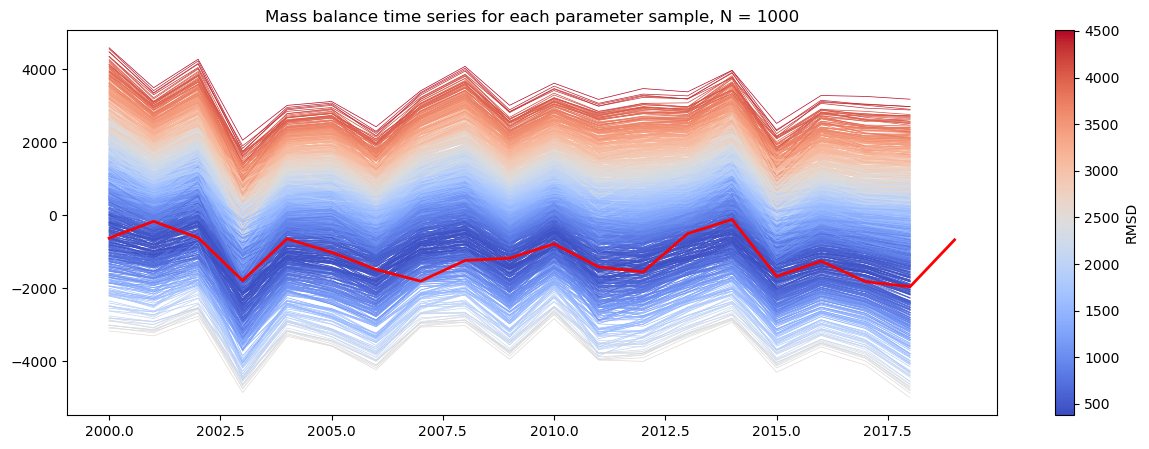

In [65]:
# compile csvs to plot timeseries and plot to view the mass balance time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
from oggm.utils import rmsd

plt.figure(figsize=(15,5))
success_index = []

# Colormap and normalization
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(15, 5))

# Using the RMSD as a metric to evaluate the success of each simulation, we can colour the lines based on the RMSD value, with a colourbar to show the range of RMSD values. 
# This will allow us to visually identify which simulations are performing better or worse in terms of matching the observed mass balance time series.
for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    success_index.append(rmsd(df['mass_balance'].values, mbdf['in_situ_mb'].loc[df['years'].iloc[0]:df['years'].iloc[-1]].values))

vmin = min(success_index)
vmax = max(success_index)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    color = cmap(norm(success_index[i]))
    plt.plot(df['years'], df['mass_balance'], label='sim', color=color, linewidth=0.5)
    plt.title('Mass balance time series for each parameter sample, N = %d' % N)

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('RMSD')

plt.plot(range(2000,2020), mbdf['in_situ_mb'].loc[2000:2019], label='obs', color='r', linewidth=2)

We can see there are some very large RMSD values here. Now let's investigate these by colour coding our parameters. Due to the very large range of temp_bias it's relationship with the other parameters, lets investigate the behaviour of the samples taken of temp_bias and see if we can reduce the range at all.

Let's perhaps choose the values with the RMSD < 10,000. This is still quite large but will narrow our range considerably.

We can investigate the relationships between the parameters and outputs with all parameter s

In [59]:
# Now let's investigate these simulations by plotting the parameters against the RMSD values, to see if we can identify any relationships between the parameters and the performance of the simulations in terms of matching the observed mass balance time series.
Y_Labels = ['Mean Runoff', 'Std of Runoff']
# Read the parameters for each simulation
params = []

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    params.append(X[i])  # Assuming X is the array of input parameters for each simulation

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])

    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], X[:, i-1], 
                         c=YY[:,j], cmap='coolwarm', edgecolors='grey')
        
        plt.ylabel(X_labels[i-1])    
        plt.xlabel(X_labels[i])      

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label(metric +'(Mt)')

    plt.show()

interact(scatter_function, metric=Y_Labels);
  

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

Now we investigate these points against the RMSD to see if the values towards the end of the scale do infact cause the RMSD to be excessively large.

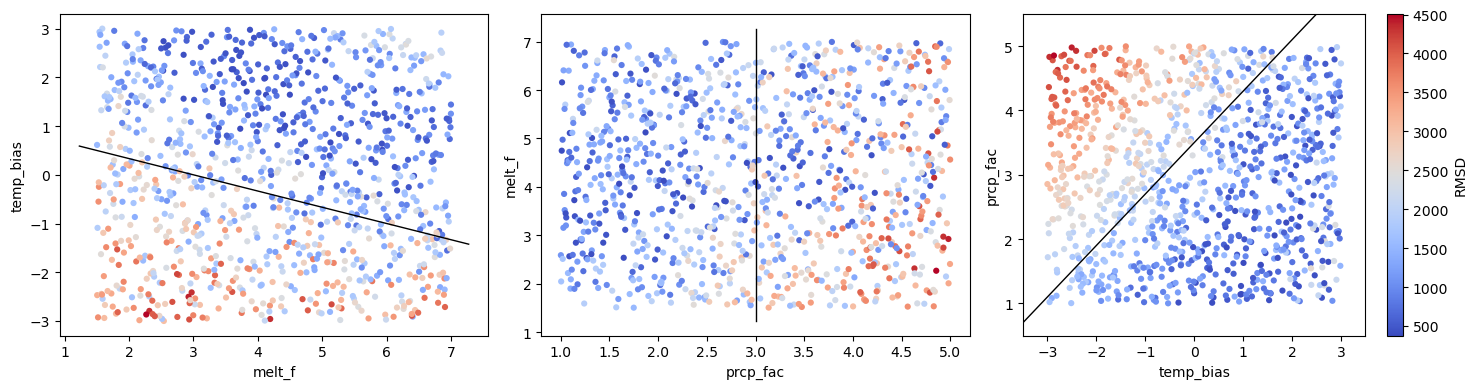

In [ ]:
from ipywidgets import interact, fixed, IntSlider
from matplotlib.pyplot import xlim, ylim

M = X.shape[1]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

success_index = np.asarray(success_index)
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=success_index.min(), vmax=success_index.max())

j = (i - 1) % X.shape[1]  # previous column (wraps around)
plt.figure(figsize=[15,4])

for i in range(M):
    plt.subplot(1,3,i+1)
    sc = plt.scatter(
        X[:, i], X[:, i-1],
        c=success_index, cmap=cmap, norm=norm, s=20, edgecolors="none"
        )
    if i == 0:   
        
        xmin, xmax = plt.xlim()
        x = np.array([xmin, xmax])
        y = -(1/3)*x + 1

        plt.plot(x, y, color='black', linewidth=1)
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])
    if i == 1:
        ymin, ymax = plt.ylim()
        y = np.array([ymin, ymax])
        x = 3 * np.ones_like(y)

        plt.plot(x, y, color='black', linewidth=1)
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])
    if i == 2:
        plt.xlim((-3.5, 3.5))
        plt.ylim((0.5, 5.5))
        xmin, xmax = plt.xlim()
        x = np.array([xmin, xmax])
        y = 0.8*x + 3.5

        plt.plot(x, y, color='black', linewidth=1)
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])

cbar = plt.colorbar(sc)
cbar.set_label("RMSD")
ax = plt.gca()

plt.tight_layout(); plt.show()


The above confirms that the high RMSD confirms with extreme values of the parametes, the RMSD is maximised, hence verifying that these parameter ranges are unrealistic. We can now work to minimise the parameter ranges within a smaller boundary of the RMSD. 

Since we have plotted these points together, we can determine some relationships to provide constraints for our samples for a more realistic parameter space.

We can see in the above graph for:
1. Relationship between the melt factor and the temperature bias, that there is almost a linear relationship split between the feasible and not-feasible combinations of these parameters. This equation can take the form as $ y = -\frac{1}{3}x + 1 $, we can bound the parameters in this way, where $y$ is the temp_bias and $x$ is the melt_f. So that $temp_b \geq -\frac{1}{3}melt_f +1$

2. For the relationship between the precipitation factor we have a rather clear linear distinction between a larger and smaller RMSD split around the function $prcp_f = 3$. The smaller RMSD region here is $prcp_f \leq 3$. The melt factor seems relatively inconsequential here and is dominated by the behaviour of the precipitation factor.

3. Now looking at the relationship between the precipitation factor and the temperature bias, there is a very clear relationship where there is a significantly larger RMSD towards significantly smaller temperature biases and larger precipitation factors. This also appears to be a linear relationship around the function $y = 0.8x + 3.5$. So we can bound the parameters so that $prcp_f /leq 0.8temp_b + 3.5$

## PAWN Sensitivity

In [16]:
# Define interactive visualisation function to calculate and visualise sensitivity indices
# for the chosen output metric and different choices of the PAWN tuning parameters (n,Nboot,aggr)

def runoff_pawn_function(metric='Mean Runoff', n = 5, aggr = 'median', Nboot = 500):
    # Extract output metric:
    if metric == 'Mean Runoff':
        i = 0
    elif metric == 'Std of Runoff':
        i = 1   
    Y = YY[:, i]; 

    X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
    
    # Apply PAWN
    # Tuning parameters:
    # n = number of conditioning intervals
    # aggr = statistic to aggregate KS values
    # Nboot = number of bootstrapping resamples used to derive confidence bounds of sensitivity indices   

    # Compute sensitivity indices for Nboot bootstrap resamples
    KS_median, KS_mean, KS_max = PAWN.pawn_indices(X, Y, n, Nboot=Nboot)
    # KS_median and KS_mean and KS_max have shape (Nboot, M)
        
    # Compute mean and confidence intervals of the sensitivity indices across the bootstrap resamples:
    KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
    KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
    KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)

    # Plot sensitivity indices:
    plt.figure()
    plt.title("Output Metric for the Runoff = %s" % metric)
    if aggr == 'median':
        pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub, X_Labels=X_labels, Y_Label='sensitivity (median KS)')
    if aggr == 'mean':
        pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub, X_Labels=X_labels, Y_Label='sensitivity (mean KS)')
    if aggr == 'max':
        pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, X_Labels=X_labels, Y_Label='sensitivity (max KS)')
    plt.show()

interact(runoff_pawn_function, metric = ['Mean Runoff','Std of Runoff'], n = (2, 20, 1), aggr = ['median', 'mean','max'], Nboot = (0, 500, 10));


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…